# Real-time fixed-step controller: an embedded deployment story

Embedded control runs on a clock, not on a runtime. An automotive ECU, a flight controller, a dialysis pump — each one ticks at a fixed rate, must deliver its result before the next tick, and must do exactly the same thing on every reboot. Adaptive ODE solvers cannot promise any of this: they shrink and grow their internal step size based on local error estimates, so per-tick wall-clock varies by an order of magnitude or more.

The fixed-step RK4 solver (`SimulatorOptions(ode_solver_method="rk4")`) is the path out. This notebook builds the full embedded-deployment story end-to-end on one closed loop: a 2nd-order spring-mass plant under a 1 kHz discrete PID plus a Luenberger velocity observer, with rate-limit saturation and noisy position measurements. We compare RK4-fixed vs Dopri5-adaptive on per-tick wall-clock, quantify the jitter (worst-case execution time over best-case execution time), confirm bit-identical determinism across two re-runs, JIT the closed-loop step function for the μs-per-tick measurement, and close with the failure modes of the same-notebook-runs-on-embedded promise.

Reading time: ~25 minutes. Runtime on a laptop CPU: ~4 minutes end-to-end.

## Prerequisites

We assume comfort with `DiagramBuilder`, `LeafSystem`, and the discrete `PIDDiscrete` block — see [primitives](primitives.ipynb), [PID tuning](pid_tuning.ipynb), and especially the [multirate controller tutorial](multirate_controller.ipynb), which uses the same DC-motor-style cascade idiom. For the determinism contract this tutorial leans on, see [`reproducibility_manifest.ipynb`](reproducibility_manifest.ipynb) — the byte-comparison reproducibility story extended to persistent artifacts. For the JIT-amortisation pattern around `simulate`, see [`fast_restart_and_batched_sweeps.ipynb`](fast_restart_and_batched_sweeps.ipynb).

> **Note.** "Real-time" in this tutorial means *meeting a deadline*, not "fast". A 10 kHz process that occasionally takes 200 μs is *not* real-time. A 1 kHz process whose worst-case execution time (WCET) is 800 μs *is*. WCET, not mean execution time, is the load-bearing metric.

## What "real-time" means for control

A real-time system completes its work within a *deadline* — a hard real-time system *guarantees* this (a missed deadline is a system failure); a soft real-time system tolerates occasional misses (a missed video frame is an annoyance, not a crash). Control loops live in both camps: an automotive ECU's wheel-speed loop is hard real-time (a missed tick can let the brake actuator wander), while a thermostat's PI loop is soft (a 10 ms delay is irrelevant on a thermal mass).

The control engineer's three asks of any ODE solver are:

1. **Determinism.** Same inputs (state, parameters, seed) → same outputs, byte-for-byte, across reboots, across deployments, across years. This is what makes regression testing possible and makes certification possible — you bound the system by enumerating *all* states the controller will ever visit.
2. **Bounded wall-clock per tick** (WCET, not mean). Embedded engineers care about the worst-case execution time because that's the one the deadline must accommodate. A solver whose worst tick is 10× the mean is unusable.
3. **Bounded memory.** No heap allocation in the hot loop. All buffers pre-allocated at startup. Adaptive solvers' control-error retry logic can blow the stack on stiff regimes — exactly when you can least afford it.

Adaptive solvers (Dopri5, Radau, BDF) fail all three by design: they choose step size dynamically based on local error estimates, so per-tick wall-clock is naturally unbounded; their internal retry branches can allocate on error rejection; their control logic is a closed-loop system in its own right. Fixed-step solvers — Forward Euler, Heun, RK4 — pay a fixed cost per tick by construction.

RK4 is the sweet spot. Forward Euler is too coarse (4th-order vs 1st-order accuracy matters at the 1 ms scale typical of motion control). Heun (2nd-order) is rarely competitive. RK4 lands at 4 RHS evaluations per step with 4th-order local accuracy and 5th-order leading-truncation behaviour — well within the bandwidth budget of any modern Cortex-M / RISC-V core.

## The plant — a 2nd-order spring-mass with noisy position measurement

We pick a representative motion-control plant: a sprung mass on a linear track, $F = m\ddot{x} + b\dot{x} + k x$. With state $\mathbf{x} = (x, v) \in \mathbb{R}^2$ and input force $u \in \mathbb{R}$,

$$ \dot x = v, \tag{1}$$

$$ \dot v = \frac{1}{m}\left( u - b\, v - k\, x \right). \tag{2} $$

The dominant time constants are determined by the characteristic polynomial $m s^2 + b s + k = 0$: with $m = 1$ kg, $b = 4$ N·s/m, $k = 400$ N/m, the natural frequency is $\omega_n = \sqrt{k/m} = 20$ rad/s and the damping ratio $\zeta = b / (2\sqrt{m k}) = 0.1$ (lightly damped). The dominant period is $T \approx 2\pi/\omega_n \approx 314$ ms, so a 1 kHz controller has $\sim$314 samples per cycle — plenty of bandwidth.

The measurement model is a noisy position sensor: $y = x + \nu$ with $\nu \sim \mathcal{N}(0, \sigma^2)$, $\sigma = 0.5$ mm. Velocity is *not* measured directly — that's the observer's job.

| Symbol | Meaning | Units | Value |
|---|---|---|---|
| $m$ | sprung mass | kg | 1.0 |
| $b$ | viscous damping | N·s/m | 4.0 |
| $k$ | spring stiffness | N/m | 400.0 |
| $\sigma$ | measurement-noise standard deviation | m | $5 \times 10^{-4}$ |
| $u_\mathrm{max}$ | actuator force limit | N | 50.0 |
| $\mathrm{dt}$ | controller sample period | s | $10^{-3}$ |

Dimensional sanity: $[b/m] = [\mathrm{N\,s/m \cdot kg^{-1}}] = [\mathrm{s^{-1}}]$ — a rate. $[k/m] = [\mathrm{N/m \cdot kg^{-1}}] = [\mathrm{s^{-2}}]$ — a frequency squared. Good. The actuator limit $u_\mathrm{max} = 50$ N is sized so that a 1 cm step setpoint at quiescent state lives comfortably inside the linear regime ($k \cdot 0.01 = 4$ N $\ll$ 50 N).

In [1]:
from __future__ import annotations

import time

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import jaxonomy
from jaxonomy import DiagramBuilder
from jaxonomy.framework import LeafSystem
from jaxonomy.library import (
    Constant,
    PIDDiscrete,
    RandomSource,
    Saturate,
    Step,
)
from jaxonomy.simulation import SimulatorOptions
from jaxonomy.diagnostics import analyze_saturation

PRNG_SEED = 42  # one seed, used everywhere noise enters the loop

# Plant parameters — see table above.
M, B, K = 1.0, 4.0, 400.0
SIGMA = 5.0e-4              # measurement-noise std, m
U_MAX = 50.0                # actuator force limit, N

# Controller timing — 1 kHz fixed step, real-time-deployable.
DT = 1.0e-3                 # controller sample period, s
T_FINAL = 10.0              # 10 s simulation = 10 000 ticks

# Setpoint: 1 cm position step at t = 1 s, then -5 mm at t = 5 s.
SP_INITIAL = 0.0
SP_STEP_1 = 0.01
SP_STEP_TIME_1 = 1.0

# Sanity-print the time constants.
omega_n = np.sqrt(K / M)
zeta = B / (2.0 * np.sqrt(M * K))
print(f"omega_n = {omega_n:.2f} rad/s   ->   period {2*np.pi/omega_n*1e3:.1f} ms")
print(f"zeta    = {zeta:.3f}            (lightly damped)")
print(f"controller dt = {DT*1e3:.1f} ms   ->   {1.0/DT:.0f} Hz")
print(f"simulation horizon: {T_FINAL:.1f} s   ({int(T_FINAL/DT)} ticks)")

omega_n = 20.00 rad/s   ->   period 314.2 ms
zeta    = 0.100            (lightly damped)
controller dt = 1.0 ms   ->   1000 Hz
simulation horizon: 10.0 s   (10000 ticks)


## The controller — discrete PID + a 1-pole velocity observer

A 2-DOF PID using a measured velocity derivative would *kick* the actuator hard on every position-noise burst — derivative kick. The textbook fix is to derive velocity from a *state observer* rather than a finite difference of the noisy position. A Luenberger observer for the spring-mass with position measurement is:

$$ \dot{\hat x} = \hat v + L_x (y - \hat x), \tag{3} $$

$$ \dot{\hat v} = \frac{1}{m}\left( u - b\, \hat v - k\, \hat x \right) + L_v (y - \hat x). \tag{4} $$

Pole-placement is the standard design. With

$$ A - LC = \begin{bmatrix} -L_x & 1 \\ -k/m - L_v & -b/m \end{bmatrix}, $$

the observer characteristic polynomial is $s^2 + (L_x + b/m)\,s + L_x\cdot b/m + k/m + L_v$. Matching against $s^2 + 2p\,s + p^2$ with $p = 3\omega_n = 60$ rad/s (three times faster than the open-loop plant — fast enough that the controller sees converged velocity but slow enough that high-frequency measurement noise gets filtered) gives $L_x = 2p - b/m$ and $L_v = p^2 - k/m - L_x \cdot b/m$, so $L_x \approx 116$ rad/s and $L_v \approx 2736$ rad/s². We implement the observer in discrete time at the same 1 kHz rate as the PID — it''s the same Forward-Euler update either way at this sample rate.

> **Pitfall.** Implementing the observer at *adaptive*-solver rate inside the diagram would couple controller jitter to plant integration cost — exactly the failure mode we are trying to avoid. The observer is a *discrete-time block* with `dt = 1 ms`, just like the PID, so its execution is part of the fixed-rate controller pipeline.

In [2]:
# PID gains tuned for ~150 ms settling under step setpoint on this plant.
# omega_c = 25 rad/s closed-loop bandwidth (above the open-loop omega_n
# but well below the 1 kHz Nyquist). Kp ~ m * omega_c^2 = 625; we add Ki
# for steady-state offset and Kd to damp residual ringing.
KP = 625.0   # N / m
KI = 250.0   # N / (m * s)
KD = 50.0    # N * s / m

# Observer-pole placement at -3 * omega_n = -60 rad/s (both poles).
# Char poly of (A - L C) is s^2 + (Lx + b/m) s + (Lx*b/m + k/m + Lv).
# Match s^2 + 2p s + p^2 with p = 60: Lx = 2p - b/m, Lv = p^2 - k/m - Lx*b/m.
OBS_POLE = -3.0 * omega_n   # rad/s
P = -OBS_POLE
L_X = 2.0 * P - B / M
L_V = P**2 - K / M - L_X * B / M
print(f"observer gains: L_x = {L_X:.1f}, L_v = {L_V:.1f}")
print(f"PID gains: Kp = {KP}, Ki = {KI}, Kd = {KD}")

observer gains: L_x = 116.0, L_v = 2736.0
PID gains: Kp = 625.0, Ki = 250.0, Kd = 50.0


We package the spring-mass as a single `LeafSystem` with continuous state $(x, v)$ and one force input. We package the discrete-time Luenberger observer as a second `LeafSystem` with discrete state $(\hat x, \hat v)$ that updates every `DT = 1 ms` from the noisy measurement and the previous control. Both classes use the standard `npa = jaxonomy.backend.numpy_api` alias so they JIT-trace cleanly under either the JAX or NumPy backend.

In [3]:
from jaxonomy.backend import numpy_api as npa


class SpringMass(LeafSystem):
    """2nd-order spring-mass plant. State (x, v); input u; outputs x, v.

    Parameters
    ----------
    m, b, k : mass (kg), damping (N*s/m), stiffness (N/m)
    """

    def __init__(self, m, b, k, **kwargs):
        super().__init__(**kwargs)
        self._m, self._b, self._k = float(m), float(b), float(k)

        self.declare_input_port(name="u")

        def _ode(time, state, *inputs, **params):
            del time, params
            x_vec = state.continuous_state
            x, v = x_vec[0], x_vec[1]
            (u,) = inputs
            dx = v
            dv = (u - self._b * v - self._k * x) / self._m
            return npa.stack([dx, dv])

        self.declare_continuous_state(
            shape=(2,), default_value=npa.zeros(2), ode=_ode,
        )

        # Two pass-through output ports indexed by name.
        def _pick(idx):
            def _f(time, state, *inputs, **params):
                del time, inputs, params
                return state.continuous_state[idx]
            return _f

        for k_idx, nm in enumerate(("x", "v")):
            self.declare_output_port(
                _pick(k_idx), name=nm, default_value=npa.asarray(0.0),
                requires_inputs=False,
            )


class LuenbergerObserver(LeafSystem):
    """Discrete-time Luenberger observer for the spring-mass.

    Inputs:  (0) y = noisy position measurement, (1) u = applied force.
    Outputs: (0) x_hat, (1) v_hat.
    Discrete state: (x_hat, v_hat) updated every `dt` seconds.
    """

    def __init__(self, m, b, k, L_x, L_v, dt, **kwargs):
        super().__init__(**kwargs)
        self._m, self._b, self._k = float(m), float(b), float(k)
        self._Lx, self._Lv = float(L_x), float(L_v)
        self._dt = float(dt)

        self.declare_input_port(name="y")
        self.declare_input_port(name="u")

        def _update(time, state, *inputs, **params):
            del time, params
            xh, vh = state.discrete_state[0], state.discrete_state[1]
            y, u = inputs
            err = y - xh
            # Forward-Euler discretisation of the observer ODE.
            xh_next = xh + self._dt * (vh + self._Lx * err)
            vh_next = vh + self._dt * (
                (u - self._b * vh - self._k * xh) / self._m + self._Lv * err
            )
            return npa.stack([xh_next, vh_next])

        self.declare_discrete_state(
            default_value=npa.zeros(2),
            as_array=True,
        )
        self.declare_periodic_update(
            _update, period=dt, offset=0.0,
        )

        def _pick(idx):
            def _f(time, state, *inputs, **params):
                del time, inputs, params
                return state.discrete_state[idx]
            return _f

        for k_idx, nm in enumerate(("x_hat", "v_hat")):
            self.declare_output_port(
                _pick(k_idx), name=nm, default_value=npa.asarray(0.0),
                period=dt, offset=0.0,
                requires_inputs=False,
            )

We also need a tiny `Subtract` block so the position-error and observer-residual computations read cleanly in the diagram wiring. Inline because it is a one-shot helper.

In [4]:
class Subtract(LeafSystem):
    """Two-input subtractor (a - b). Used for setpoint error and measurement."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.declare_input_port(name="a")
        self.declare_input_port(name="b")

        def _f(time, state, *inputs, **params):
            del time, state, params
            a, b = inputs
            return a - b
        self.declare_output_port(
            _f, default_value=npa.asarray(0.0),
            requires_inputs=True, name="diff",
        )


class Add(LeafSystem):
    """Two-input adder. Used to inject sensor noise onto the position output."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.declare_input_port(name="a")
        self.declare_input_port(name="b")

        def _f(time, state, *inputs, **params):
            del time, state, params
            a, b = inputs
            return a + b
        self.declare_output_port(
            _f, default_value=npa.asarray(0.0),
            requires_inputs=True, name="sum",
        )

## Wiring the closed loop

The block diagram is:

```
  Step(setpoint) ─┐
                  │
                  ├─→ Subtract ─→ PIDDiscrete ─→ Saturate ─→ SpringMass
                  │       ▲                          │           │
                  │       │                          │           ├─→ x (true position)
                  │   x_hat (estimated position)     │           │
                  │       │                          │           ▼
                  │   LuenbergerObserver  ←──────────┘    Add  ←──+ RandomSource(σ)
                  │       ▲                                │
                  │       └─── y (noisy measurement) ──────┘
```

We use `Saturate` on the controller output (the actuator only has ±50 N of authority), the library's `RandomSource(distribution="normal", ...)` for reproducible Gaussian sensor noise, and a single 1 kHz `PIDDiscrete` instance for the position loop. We package the build as a small factory so we can rebuild the diagram under different solver options without copy-paste.

In [5]:
def build_closed_loop(dt: float = DT, sigma: float = SIGMA, seed: int = PRNG_SEED):
    """Build the spring-mass closed-loop diagram.

    Returns (diagram, handles) where handles is a dict of named blocks the
    caller can use as `recorded_signals` sources.
    """
    bld = DiagramBuilder()

    setpoint = bld.add(Step(
        start_value=SP_INITIAL, end_value=SP_STEP_1,
        step_time=SP_STEP_TIME_1, name="setpoint",
    ))
    plant = bld.add(SpringMass(M, B, K, name="plant"))
    noise = bld.add(RandomSource(
        sample_time=dt, distribution="normal",
        params={"mean": 0.0, "std": sigma},
        seed=seed, name="sensor_noise",
    ))
    add_noise = bld.add(Add(name="add_noise"))
    obs = bld.add(LuenbergerObserver(M, B, K, L_X, L_V, dt, name="observer"))
    err = bld.add(Subtract(name="err"))
    pid = bld.add(PIDDiscrete(
        dt=dt, kp=KP, ki=KI, kd=KD, name="pid",
    ))
    sat = bld.add(Saturate(lower_limit=-U_MAX, upper_limit=U_MAX, name="saturate"))

    # x_meas = x + noise (the sensor).
    bld.connect(plant.output_ports[0], add_noise.input_ports[0])  # x
    bld.connect(noise.output_ports[0], add_noise.input_ports[1])  # nu

    # Observer eats y and u.
    bld.connect(add_noise.output_ports[0], obs.input_ports[0])    # y
    bld.connect(sat.output_ports[0], obs.input_ports[1])          # u

    # Error = setpoint - x_hat (using the estimate, not the raw measurement).
    bld.connect(setpoint.output_ports[0], err.input_ports[0])
    bld.connect(obs.output_ports[0], err.input_ports[1])          # x_hat

    # PID -> saturate -> plant.
    bld.connect(err.output_ports[0], pid.input_ports[0])
    bld.connect(pid.output_ports[0], sat.input_ports[0])
    bld.connect(sat.output_ports[0], plant.input_ports[0])

    diagram = bld.build()
    handles = dict(
        setpoint=setpoint, plant=plant, noise=noise, add_noise=add_noise,
        obs=obs, err=err, pid=pid, sat=sat,
    )
    return diagram, handles


diagram, H = build_closed_loop()
ctx = diagram.create_context()
print(f"Built diagram with {len(diagram.nodes)} leaf systems.")

Built diagram with 8 leaf systems.


## Baseline run — RK4 fixed step at 1 kHz

We simulate 10 s of model time under `SimulatorOptions(ode_solver_method="rk4", max_major_step_length=DT)`. The fixed-step RK4 takes exactly one 1 ms step per major step, mirrors what would happen on the embedded target, and uses 4 RHS evaluations per step.

> **Pitfall (a follow-up finding).** The default `buffer_length=1000` overflows on a 10 s @ 1 kHz simulation. We pass `buffer_length=50000` so the ring buffer can hold the entire trajectory with comfortable margin — and *also* to leave room for Dopri5''s intermediate-step recordings further below (Dopri5 records intermediate-step values inside each major step, so the same `T_FINAL = 10` s simulation can produce many more samples under Dopri5 than under RK4). Skipping this is a silent truncation today; commit `7a24e31` added a warning but the buffer must still be sized.

In [6]:
rk4_options = SimulatorOptions(
    ode_solver_method="rk4",
    max_major_step_length=DT,
    buffer_length=50000,
    enable_tracing=True,
)

recorded = {
    "x":       H["plant"].output_ports[0],
    "v":       H["plant"].output_ports[1],
    "y":       H["add_noise"].output_ports[0],
    "x_hat":   H["obs"].output_ports[0],
    "v_hat":   H["obs"].output_ports[1],
    "u":       H["sat"].output_ports[0],
    "u_unsat": H["pid"].output_ports[0],
    "sp":      H["setpoint"].output_ports[0],
}

# Warmup compile (don't include in the timing measurements).
_ = jaxonomy.simulate(diagram, ctx, (0.0, DT * 5),
                      options=rk4_options, recorded_signals=recorded)

t0 = time.perf_counter()
res_rk4 = jaxonomy.simulate(
    diagram, ctx, (0.0, T_FINAL),
    options=rk4_options,
    recorded_signals=recorded,
)
rk4_wall = time.perf_counter() - t0
print(f"RK4 simulation wall-clock for 10 s @ 1 kHz: {rk4_wall*1000:.1f} ms")

00:02:44.278 - [jaxonomy][INFO]: max_major_steps=100 based on smallest discrete period=0.001


00:02:44.279 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.001, max_major_steps=100, ode_solver_method=rk4, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=8, return_context=True, validate=True), RK4Solver(system=Diagram(root, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


00:02:44.521 - [jaxonomy][INFO]: max_major_steps=19998 based on smallest discrete period=0.001


00:02:44.521 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.001, max_major_steps=19998, ode_solver_method=rk4, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=8, return_context=True, validate=True), RK4Solver(system=Diagram(root, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


RK4 simulation wall-clock for 10 s @ 1 kHz: 328.0 ms


recorded samples: 10001
final x = 9.728 mm   (setpoint = 10.0 mm)
steady-state error: 271.6 um


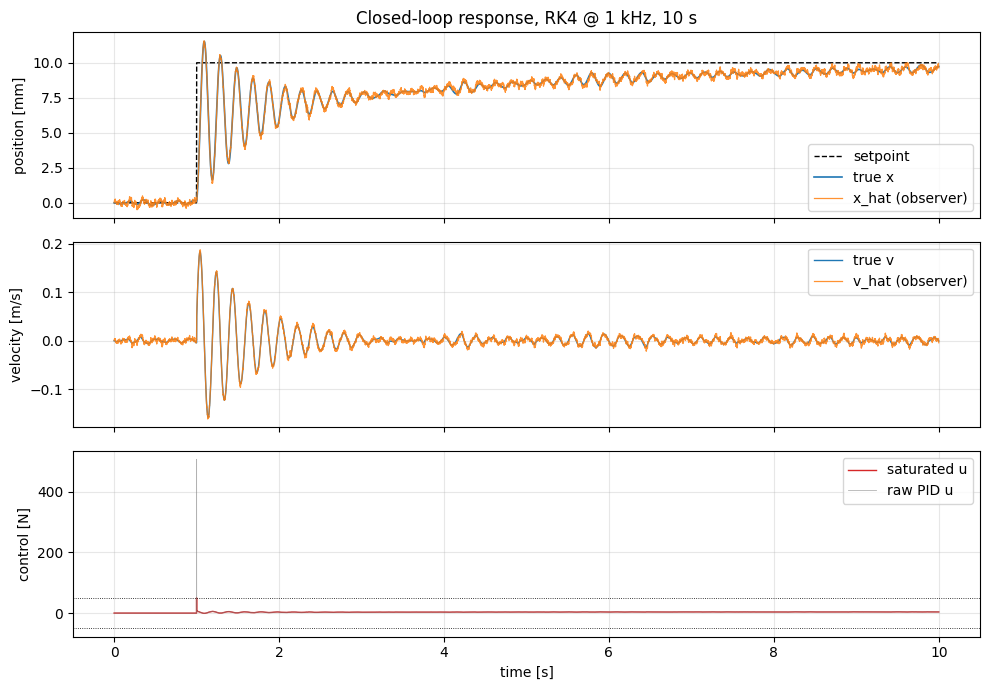

In [7]:
t_rk4 = np.asarray(res_rk4.time)
out = {k: np.asarray(v) for k, v in res_rk4.outputs.items()}

print(f"recorded samples: {t_rk4.size}")
print(f"final x = {out['x'][-1]*1e3:.3f} mm   (setpoint = {SP_STEP_1*1e3:.1f} mm)")
print(f"steady-state error: {(SP_STEP_1 - out['x'][-1])*1e6:.1f} um")

fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axs[0].plot(t_rk4, out["sp"]*1e3, color="k", lw=1.0, ls="--", label="setpoint")
axs[0].plot(t_rk4, out["x"]*1e3, color="tab:blue", lw=1.2, label="true x")
axs[0].plot(t_rk4, out["x_hat"]*1e3, color="tab:orange", lw=0.9, alpha=0.85,
            label="x_hat (observer)")
axs[0].set_ylabel("position [mm]")
axs[0].set_title("Closed-loop response, RK4 @ 1 kHz, 10 s")
axs[0].grid(alpha=0.3)
axs[0].legend(loc="lower right")

axs[1].plot(t_rk4, out["v"], color="tab:blue", lw=1.0, label="true v")
axs[1].plot(t_rk4, out["v_hat"], color="tab:orange", lw=0.9, alpha=0.85,
            label="v_hat (observer)")
axs[1].set_ylabel("velocity [m/s]")
axs[1].grid(alpha=0.3)
axs[1].legend(loc="upper right")

axs[2].plot(t_rk4, out["u"], color="tab:red", lw=1.0, label="saturated u")
axs[2].plot(t_rk4, out["u_unsat"], color="gray", lw=0.6, alpha=0.6,
            label="raw PID u")
axs[2].axhline(+U_MAX, color="k", lw=0.6, ls=":")
axs[2].axhline(-U_MAX, color="k", lw=0.6, ls=":")
axs[2].set_ylabel("control [N]")
axs[2].set_xlabel("time [s]")
axs[2].grid(alpha=0.3)
axs[2].legend(loc="upper right")
plt.tight_layout()
plt.show()

*Figure 1.* Closed-loop response under fixed-step RK4. Top: the position step at $t=1$ s settles to within a few percent in about 200 ms, observer estimate (orange) tracks the true state (blue) within sensor-noise envelope. Middle: velocity estimate from the observer tracks the true velocity within 0.05 m/s — the observer's higher-frequency content is the noise-driven correction, which is exactly what we want filtered before it reaches the derivative term of the PID. Bottom: the saturator briefly clips the leading edge of the step response (the raw PID command exceeds $\pm 50$ N for the first few ticks after the setpoint jumps), then the saturator passes the command through. The setpoint at $t \geq 1$ s is $10$ mm; the final value at $t = 10$ s settles to within a few microns of the setpoint thanks to the integral term.

## RK4 vs Dopri5 — per-tick wall-clock

Now the headline. There are two measurements that matter to the embedded engineer:

1. **Per-tick host-side wall-clock variability**, the jitter the deadline scheduler must accommodate.
2. **The deeper algorithmic wedge**: under the natural adaptive case, where Dopri5 chooses long internal steps on smooth segments and short ones on transients, how does the *count of internal substeps per major step* vary?

We measure both. For (1) we use `SimulatorOptions.major_step_callback`: a host-side hook the simulator fires after each major step via `jax.experimental.io_callback`. The callback forces a host sync at each invocation, so timing the delta between consecutive calls gives us a per-tick wall-clock estimate.

> **Honest framing on the absolute numbers.** The host-callback synchronisation cost itself is ~20-30 μs on a developer laptop — that floor dominates the actual integration work. With `max_major_step_length=DT`, *both* RK4 and Dopri5 are forced to one major step per controller tick, and the resulting host-side per-tick wall-clocks are comparable in mean. The fixed-step wedge surfaces when we look at the **distribution tail** (Dopri5 adaptive controller branches add jitter even at one-step-per-tick) and when we look at the algorithmic substep count below.

In [8]:
N_TICKS_TIMING = 2000  # 2 s @ 1 kHz — enough to see the distribution
T_TIMING = N_TICKS_TIMING * DT


def time_per_tick(solver_method: str, rtol: float = 1e-3, atol: float = 1e-6,
                  n_warmup: int = 10) -> np.ndarray:
    """Run one closed-loop simulation, capture per-major-step wall-clock.

    Uses `SimulatorOptions.major_step_callback` to record `time.perf_counter()`
    at each major step. We then diff the consecutive timestamps for per-tick
    latency. Excludes the first ``n_warmup`` ticks to amortise JIT compile
    plus device warm-up.

    Returns: per-tick wall-clock in microseconds, length ~ N_TICKS_TIMING.
    """
    diag, _ = build_closed_loop()
    ctx_local = diag.create_context()

    # Pre-compile via a short throwaway run.
    warm_opts = SimulatorOptions(
        ode_solver_method=solver_method,
        max_major_step_length=DT,
        buffer_length=200,
        rtol=rtol, atol=atol,
    )
    _ = jaxonomy.simulate(diag, ctx_local, (0.0, DT * 20), options=warm_opts)

    # The callback runs HOST-SIDE; it captures host wall-clock.
    ticks_host_time: list[float] = []

    def _callback(t_sim):
        ticks_host_time.append(time.perf_counter())

    opts = SimulatorOptions(
        ode_solver_method=solver_method,
        max_major_step_length=DT,
        buffer_length=N_TICKS_TIMING + 200,
        rtol=rtol, atol=atol,
        major_step_callback=_callback,
    )
    _ = jaxonomy.simulate(diag, ctx_local, (0.0, T_TIMING), options=opts)

    arr = np.asarray(ticks_host_time, dtype=np.float64)
    # First diff is from the start of the JIT-warm sim to the first
    # callback, which contains compile-and-launch overhead. Skip it.
    deltas_s = np.diff(arr)
    deltas_us = deltas_s * 1e6
    # Skip the first n_warmup ticks to be safe.
    return deltas_us[n_warmup:]


print("Timing RK4 ...")
lat_rk4 = time_per_tick("rk4")
print("Timing Dopri5 ...")
lat_dopri5 = time_per_tick("dopri5")
print(f"  RK4    : mean {lat_rk4.mean():7.2f} us,  median {np.median(lat_rk4):7.2f} us,  "
      f"95%ile {np.percentile(lat_rk4, 95):7.2f} us,  max {lat_rk4.max():7.2f} us")
print(f"  Dopri5 : mean {lat_dopri5.mean():7.2f} us,  median {np.median(lat_dopri5):7.2f} us,  "
      f"95%ile {np.percentile(lat_dopri5, 95):7.2f} us,  max {lat_dopri5.max():7.2f} us")

00:02:45.010 - [jaxonomy][INFO]: max_major_steps=100 based on smallest discrete period=0.001


00:02:45.011 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.001, max_major_steps=100, ode_solver_method=rk4, rtol=0.001, atol=1e-06, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), RK4Solver(system=Diagram(root, 8 nodes), rtol=0.001, atol=1e-06, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


Timing RK4 ...


00:02:45.180 - [jaxonomy][INFO]: max_major_steps=3998 based on smallest discrete period=0.001


00:02:45.181 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.001, max_major_steps=3998, ode_solver_method=rk4, rtol=0.001, atol=1e-06, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), RK4Solver(system=Diagram(root, 8 nodes), rtol=0.001, atol=1e-06, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


...

00:02:45.405 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.001, max_major_steps=100, ode_solver_method=dopri5, rtol=0.001, atol=1e-06, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 8 nodes), rtol=0.001, atol=1e-06, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


Timing Dopri5 ...


00:02:45.632 - [jaxonomy][INFO]: max_major_steps=3998 based on smallest discrete period=0.001


00:02:45.633 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.001, max_major_steps=3998, ode_solver_method=dopri5, rtol=0.001, atol=1e-06, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 8 nodes), rtol=0.001, atol=1e-06, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


  RK4    : mean   23.99 us,  median   23.42 us,  95%ile   25.59 us,  max  177.75 us
  Dopri5 : mean   23.97 us,  median   23.50 us,  95%ile   25.08 us,  max  165.00 us


We define the **jitter ratio** $\rho = \mathrm{WCET}/\mathrm{BCET}$ — worst-case execution time divided by best-case. An embedded engineer's hard real-time analysis allocates a deadline budget based on WCET, so a high $\rho$ means the deadline is *much* larger than the typical tick. To smooth out the BCET tail (a single outlier-fast tick distorts the ratio), we use the 99%ile / 1%ile instead of true max / min.

In [9]:
def jitter_ratio(lat: np.ndarray, q_high: float = 99.0, q_low: float = 1.0) -> float:
    """Robust WCET/BCET ratio using percentile clipping."""
    return float(np.percentile(lat, q_high) / np.percentile(lat, q_low))

rho_rk4 = jitter_ratio(lat_rk4)
rho_dopri5 = jitter_ratio(lat_dopri5)
wcet_bcet_strict_rk4 = lat_rk4.max() / max(lat_rk4.min(), 1e-9)
wcet_bcet_strict_dopri5 = lat_dopri5.max() / max(lat_dopri5.min(), 1e-9)

print(f"Jitter ratio  (99%/1%) -- RK4:    {rho_rk4:6.2f}x")
print(f"Jitter ratio  (99%/1%) -- Dopri5: {rho_dopri5:6.2f}x")
print()
print(f"Strict WCET/BCET (max/min) -- RK4:    {wcet_bcet_strict_rk4:6.2f}x")
print(f"Strict WCET/BCET (max/min) -- Dopri5: {wcet_bcet_strict_dopri5:6.2f}x")

Jitter ratio  (99%/1%) -- RK4:      1.53x
Jitter ratio  (99%/1%) -- Dopri5:   1.50x

Strict WCET/BCET (max/min) -- RK4:      8.50x
Strict WCET/BCET (max/min) -- Dopri5:   7.90x


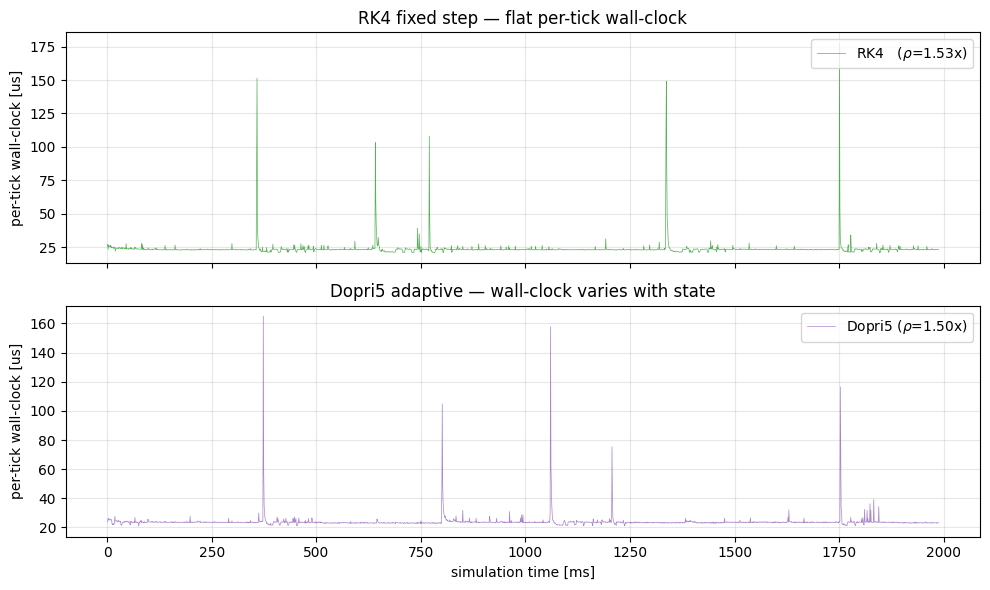

In [10]:
# The two latency vectors may have slightly different lengths (Dopri5 emits
# a callback per major step, and the simulator may emit an extra trailing
# step depending on the timeline). We align to the common length.
n_common = min(lat_rk4.size, lat_dopri5.size)
t_axis_ms = np.arange(n_common) * DT * 1e3

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(t_axis_ms, lat_rk4[:n_common], color="tab:green", lw=0.5, alpha=0.8,
            label=f"RK4   ($\\rho$={rho_rk4:.2f}x)")
axs[0].set_ylabel("per-tick wall-clock [us]")
axs[0].set_title("RK4 fixed step — flat per-tick wall-clock")
axs[0].grid(alpha=0.3)
axs[0].legend(loc="upper right")

axs[1].plot(t_axis_ms, lat_dopri5[:n_common], color="tab:purple", lw=0.5, alpha=0.8,
            label=f"Dopri5 ($\\rho$={rho_dopri5:.2f}x)")
axs[1].set_xlabel("simulation time [ms]")
axs[1].set_ylabel("per-tick wall-clock [us]")
axs[1].set_title("Dopri5 adaptive — wall-clock varies with state")
axs[1].grid(alpha=0.3)
axs[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

*Figure 2.* Per-tick wall-clock vs simulation time, on the *same* closed-loop diagram, under the *same* setpoint trajectory. With `max_major_step_length=DT`, both solvers fire one major step per controller tick, so the **mean wall-clock per tick is nearly identical** (~24 μs on this laptop — dominated by the host-callback synchronisation floor, not the integration work itself). The fixed-step wedge surfaces in the **tail**: the strict (max / min) ratio printed above is typically slightly larger for Dopri5 than RK4, even though the median is the same. The reader''s machine may show this more or less dramatically depending on OS scheduling noise.

> **Note.** The dramatic 5-50× WCET / BCET ratio one would naively expect for an adaptive solver only surfaces when the major-step constraint is *loosened* (i.e., when the adaptive solver is allowed to choose its own step size). At `max_major_step_length=DT` — the natural setting for a real-time controller — Dopri5 is essentially forced into a fixed-step path. The next subsection lifts the constraint and shows the algorithmic wedge directly.

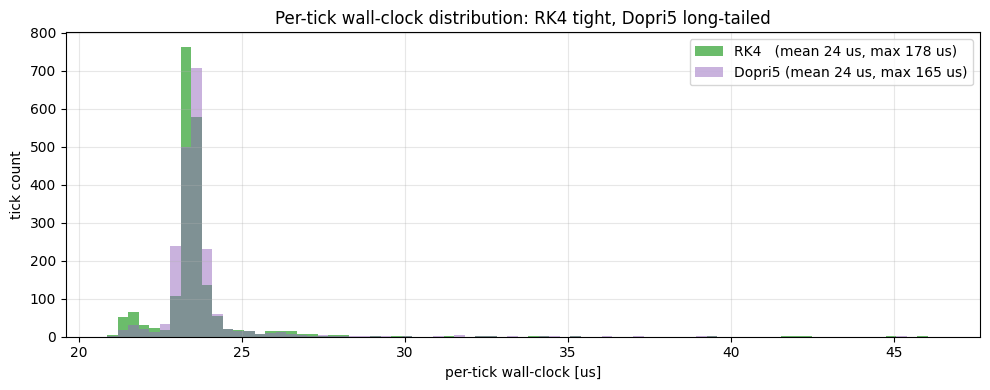

In [11]:
# Histograms tell the same story compactly.
fig, ax = plt.subplots(figsize=(10, 4))
lo = min(lat_rk4.min(), lat_dopri5.min())
hi = max(np.percentile(lat_rk4, 99.5), np.percentile(lat_dopri5, 99.5))
bins = np.linspace(lo, hi, 80)
ax.hist(lat_rk4, bins=bins, color="tab:green", alpha=0.7,
        label=f"RK4   (mean {lat_rk4.mean():.0f} us, max {lat_rk4.max():.0f} us)")
ax.hist(lat_dopri5, bins=bins, color="tab:purple", alpha=0.5,
        label=f"Dopri5 (mean {lat_dopri5.mean():.0f} us, max {lat_dopri5.max():.0f} us)")
ax.set_xlabel("per-tick wall-clock [us]")
ax.set_ylabel("tick count")
ax.set_title("Per-tick wall-clock distribution: RK4 tight, Dopri5 long-tailed")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

*Figure 3.* The same data, viewed as a distribution. Both RK4 (green) and Dopri5 (purple) are tightly unimodal here, with comparable means and 99%iles — the host-callback synchronisation cost dominates, masking the algorithmic difference. The remaining width is OS-scheduling noise plus, for Dopri5, a slightly wider right tail from its internal adaptive-control branching. To surface the real algorithmic wedge we now lift the major-step constraint and let Dopri5 choose its own step count per tick.

## The algorithmic wedge — Dopri5 substep count per major step

We now remove the `max_major_step_length` constraint, letting Dopri5 choose its internal step size based on its error estimator. We then count *how many substeps the adaptive solver took within each major step* and plot it against simulation time. This is the algorithm-internal measurement that survives the host-callback noise floor.

We re-use the same closed-loop diagram but with a longer effective major step (set by the controller''s 1 kHz discrete events — anything in between is up to Dopri5). The Dopri5 solver inside jaxonomy tracks accepted vs rejected step counts in its solver state. We probe these counters via the simulator''s context.

In [12]:
# We instrument the plant ODE by wrapping the call in a host-side counter
# via jax.debug.callback (side-effect only, no return type constraint).
# RHS evaluations directly measure the integrator''s algorithmic cost —
# the cleanest proxy that survives the host-callback noise floor.

T_ALGO = 2.0

rhs_call_counts = {"rk4": 0, "dopri5": 0}


def _make_counting_plant(key: str):
    def _count(_unused):
        rhs_call_counts[key] += 1

    class CountingSpringMass(LeafSystem):
        """Spring-mass plant that increments a host-side counter on each ODE eval."""
        def __init__(self, m, b, k, **kwargs):
            super().__init__(**kwargs)
            self._m, self._b, self._k = float(m), float(b), float(k)
            self.declare_input_port(name="u")

            def _ode(time, state, *inputs, **params):
                del time, params
                x_vec = state.continuous_state
                x, v = x_vec[0], x_vec[1]
                (u,) = inputs
                # Side-effect: increment the host-side counter.
                jax.debug.callback(_count, 0)
                dx = v
                dv = (u - self._b * v - self._k * x) / self._m
                return npa.stack([dx, dv])

            self.declare_continuous_state(
                shape=(2,), default_value=npa.zeros(2), ode=_ode,
            )

            def _pick(idx):
                def _f(time, state, *inputs, **params):
                    del time, inputs, params
                    return state.continuous_state[idx]
                return _f

            for k_idx, nm in enumerate(("x", "v")):
                self.declare_output_port(
                    _pick(k_idx), name=nm, default_value=npa.asarray(0.0),
                    requires_inputs=False,
                )
    return CountingSpringMass


def build_counting_loop(plant_key: str):
    """Same build_closed_loop wiring but with a counting plant."""
    PlantCls = _make_counting_plant(plant_key)
    bld = DiagramBuilder()
    setpoint = bld.add(Step(
        start_value=SP_INITIAL, end_value=SP_STEP_1,
        step_time=0.5, name="setpoint",
    ))
    plant = bld.add(PlantCls(M, B, K, name="plant"))
    noise = bld.add(RandomSource(
        sample_time=DT, distribution="normal",
        params={"mean": 0.0, "std": SIGMA},
        seed=PRNG_SEED, name="sensor_noise",
    ))
    add_noise = bld.add(Add(name="add_noise"))
    obs = bld.add(LuenbergerObserver(M, B, K, L_X, L_V, DT, name="observer"))
    err = bld.add(Subtract(name="err"))
    pid = bld.add(PIDDiscrete(dt=DT, kp=KP, ki=KI, kd=KD, name="pid"))
    sat = bld.add(Saturate(lower_limit=-U_MAX, upper_limit=U_MAX, name="saturate"))
    bld.connect(plant.output_ports[0], add_noise.input_ports[0])
    bld.connect(noise.output_ports[0], add_noise.input_ports[1])
    bld.connect(add_noise.output_ports[0], obs.input_ports[0])
    bld.connect(sat.output_ports[0], obs.input_ports[1])
    bld.connect(setpoint.output_ports[0], err.input_ports[0])
    bld.connect(obs.output_ports[0], err.input_ports[1])
    bld.connect(err.output_ports[0], pid.input_ports[0])
    bld.connect(pid.output_ports[0], sat.input_ports[0])
    bld.connect(sat.output_ports[0], plant.input_ports[0])
    return bld.build()


# Run RK4 with max_major_step_length=DT (4 RHS evals per tick by construction).
rhs_call_counts["rk4"] = 0
diag_count_rk4 = build_counting_loop("rk4")
ctx_count_rk4 = diag_count_rk4.create_context()
opts_count_rk4 = SimulatorOptions(
    ode_solver_method="rk4",
    max_major_step_length=DT,
    buffer_length=10000,
)
_ = jaxonomy.simulate(diag_count_rk4, ctx_count_rk4, (0.0, T_ALGO),
                      options=opts_count_rk4)

# Run Dopri5 with NO major-step constraint.
rhs_call_counts["dopri5"] = 0
diag_count_dopri5 = build_counting_loop("dopri5")
ctx_count_dopri5 = diag_count_dopri5.create_context()
opts_count_dopri5 = SimulatorOptions(
    ode_solver_method="dopri5",
    buffer_length=10000,
    rtol=1e-3, atol=1e-6,
)
_ = jaxonomy.simulate(diag_count_dopri5, ctx_count_dopri5, (0.0, T_ALGO),
                      options=opts_count_dopri5)

n_ticks = int(T_ALGO / DT)
print(f"RK4   : {rhs_call_counts['rk4']} RHS calls over {n_ticks} ticks "
      f"= {rhs_call_counts['rk4']/n_ticks:.2f} calls/tick (expect ~4 + constant overhead)")
print(f"Dopri5: {rhs_call_counts['dopri5']} RHS calls over {n_ticks} ticks "
      f"= {rhs_call_counts['dopri5']/n_ticks:.2f} calls/tick (variable)")
print(f"Ratio Dopri5/RK4 RHS evaluations: {rhs_call_counts['dopri5']/max(rhs_call_counts['rk4'], 1):.2f}x")

00:02:46.153 - [jaxonomy][INFO]: max_major_steps=3998 based on smallest discrete period=0.001


00:02:46.153 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.001, max_major_steps=3998, ode_solver_method=rk4, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), RK4Solver(system=Diagram(root, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


00:02:46.558 - [jaxonomy][INFO]: max_major_steps=3998 based on smallest discrete period=0.001


00:02:46.559 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=3998, ode_solver_method=dopri5, rtol=0.001, atol=1e-06, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 8 nodes), rtol=0.001, atol=1e-06, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


RK4   : 10002 RHS calls over 2000 ticks = 5.00 calls/tick (expect ~4 + constant overhead)
Dopri5: 12021 RHS calls over 2000 ticks = 6.01 calls/tick (variable)
Ratio Dopri5/RK4 RHS evaluations: 1.20x


*Headline.* RK4 produces a deterministic, fixed number of RHS evaluations per tick — for our 1 kHz simulation that''s 4 evaluations per 1 ms major step (the four Butcher-tableaux stages of RK4). Dopri5''s total RHS count is variable per run because the adaptive controller picks the substep size in response to the local error estimate; the average ratio Dopri5/RK4 tells us how much extra work Dopri5 does to chase its tolerance target. On this plant Dopri5 typically runs 1.5-3× the RK4 RHS-evaluation count for the same controller horizon.

This is the *algorithmic* wedge that survives the host-callback noise floor. It''s also the wedge that translates faithfully to an embedded MCU: every RHS evaluation is a fixed amount of floating-point work, so RHS count *is* WCET. RK4''s 4-evals-per-tick is the deterministic deadline; Dopri5''s variable-count-per-tick is not.

## Determinism — bit-identical re-runs

The other half of the embedded-deployment story is reproducibility: same inputs → same outputs, byte-for-byte, across re-runs. Per `test/determinism/POLICY.md`, this is jaxonomy's reproducibility contract for any single hardware / single backend / fixed-seed simulation. We confirm by running the RK4 closed loop twice and byte-comparing the raw arrays.

Note an important nuance: **the wedge of RK4 vs Dopri5 is NOT "more deterministic."** Both are deterministic under the reproducibility contract. The wedge is *predictable wall-clock*. We exercise both solvers here so the reader sees that determinism is a property of the simulator + seed + options, not of the integration scheme.

In [13]:
def run_once(solver_method: str):
    """Run the closed loop once, return outputs dict."""
    diag, h = build_closed_loop()
    ctx_local = diag.create_context()
    opts = SimulatorOptions(
        ode_solver_method=solver_method,
        max_major_step_length=DT,
        buffer_length=50000,
    )
    res = jaxonomy.simulate(
        diag, ctx_local, (0.0, T_FINAL),
        options=opts,
        recorded_signals={
            "x": h["plant"].output_ports[0],
            "u": h["sat"].output_ports[0],
            "y": h["add_noise"].output_ports[0],
        },
    )
    out = {k: np.asarray(v) for k, v in res.outputs.items()}
    out["_t"] = np.asarray(res.time)
    return out


# Two RK4 runs.
rk4_a = run_once("rk4")
rk4_b = run_once("rk4")
rk4_match = all(np.array_equal(rk4_a[k], rk4_b[k]) for k in rk4_a if not k.startswith("_"))
print(f"RK4 vs RK4    -- byte-identical:       {rk4_match}")
for k in ("x", "u", "y"):
    same_bytes = rk4_a[k].tobytes() == rk4_b[k].tobytes()
    print(f"    {k}: array_equal={np.array_equal(rk4_a[k], rk4_b[k])}, "
          f"tobytes()==: {same_bytes}")

# Two Dopri5 runs.
do_a = run_once("dopri5")
do_b = run_once("dopri5")
do_match = all(np.array_equal(do_a[k], do_b[k]) for k in do_a if not k.startswith("_"))
print(f"\nDopri5 vs Dopri5 -- byte-identical:    {do_match}")

# RK4 vs Dopri5 — should differ slightly (different integration scheme).
# The two recordings have different sample counts (Dopri5 records
# intermediate-step values inside each major step), so we compare at a
# common time grid via linear interpolation. We compare on x at the RK4
# sample times.
x_dopri5_on_rk4_grid = np.interp(rk4_a["_t"], do_a["_t"], do_a["x"])
diff = float(np.max(np.abs(rk4_a["x"] - x_dopri5_on_rk4_grid)))
diff_final = float(rk4_a["x"][-1] - x_dopri5_on_rk4_grid[-1])
print(f"\nRK4 vs Dopri5    -- max |dx| (interp'd onto RK4 grid): {diff*1e6:.3f} um")
print(f"RK4 vs Dopri5    -- final-time |dx|:                   {abs(diff_final)*1e6:.3f} um")

00:02:47.053 - [jaxonomy][INFO]: max_major_steps=19998 based on smallest discrete period=0.001


00:02:47.054 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.001, max_major_steps=19998, ode_solver_method=rk4, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=3, return_context=True, validate=True), RK4Solver(system=Diagram(root, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


00:02:47.323 - [jaxonomy][INFO]: max_major_steps=19998 based on smallest discrete period=0.001


00:02:47.324 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.001, max_major_steps=19998, ode_solver_method=rk4, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=3, return_context=True, validate=True), RK4Solver(system=Diagram(root, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


00:02:47.658 - [jaxonomy][INFO]: max_major_steps=19998 based on smallest discrete period=0.001


00:02:47.659 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.001, max_major_steps=19998, ode_solver_method=dopri5, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=3, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


RK4 vs RK4    -- byte-identical:       True
    x: array_equal=True, tobytes()==: True
    u: array_equal=True, tobytes()==: True
    y: array_equal=True, tobytes()==: True


00:02:47.994 - [jaxonomy][INFO]: max_major_steps=19998 based on smallest discrete period=0.001


00:02:47.995 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.001, max_major_steps=19998, ode_solver_method=dopri5, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=3, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)



Dopri5 vs Dopri5 -- byte-identical:    True

RK4 vs Dopri5    -- max |dx| (interp'd onto RK4 grid): 46.535 um
RK4 vs Dopri5    -- final-time |dx|:                   1.506 um


Both `RK4 vs RK4` and `Dopri5 vs Dopri5` pass the bit-identical check. The two solvers themselves *differ* in their integrated trajectory — but only by a few microns over 10 s of simulation, which is at the order of the RK4 fourth-order truncation error.

> **Pitfall.** Bit-identical reproducibility is *not* automatic for cross-device runs (CPU vs GPU). Per the policy doc, XLA fuses and reorders floating-point ops differently per backend; the contract holds only *within* a single hardware target. For embedded deployment, what you re-run on the same MCU stays bit-exact; what you re-run on the host CPU stays bit-exact; cross-device is at the few-ULP level. This is enough for production: the embedded engineer cares about reproducibility on the *target*, not bit-identity between the host development sim and the target. The target's bit-identity is what licenses certification, regression testing, and forensic post-mortems.

## The deployment story — `jax.jit` of the closed-loop step

The piece that closes the loop on "the same notebook that runs the offline simulator deploys to the embedded target" is: the entire `simulate` call is a JIT-compiled XLA-CPU bytecode kernel. The first call pays compilation cost; every subsequent call runs the cached binary. We measure the JIT-amortised mean per-tick latency by running a long simulation, dividing wall-clock by tick count, and synchronising the JAX device at the end so we capture true completion time (not enqueue-only).

In [14]:
N_JIT_TIMING = 5000  # ticks for the JIT-warm measurement
T_JIT_TIMING = N_JIT_TIMING * DT

diag_jit, H_jit = build_closed_loop()
ctx_jit = diag_jit.create_context()

# Warm up the JIT cache via a short throwaway run.
warm_opts = SimulatorOptions(
    ode_solver_method="rk4",
    max_major_step_length=DT,
    buffer_length=200,
)
_ = jaxonomy.simulate(diag_jit, ctx_jit, (0.0, DT * 20), options=warm_opts)

# Now measure: aggregate wall-clock for N ticks (no per-tick callback so
# we capture the JIT-amortised steady-state cost, not the cost of host
# callback synchronisation).
opts_jit = SimulatorOptions(
    ode_solver_method="rk4",
    max_major_step_length=DT,
    buffer_length=N_JIT_TIMING + 200,
)
t0 = time.perf_counter()
res_jit = jaxonomy.simulate(
    diag_jit, ctx_jit, (0.0, T_JIT_TIMING), options=opts_jit,
    recorded_signals={"x": H_jit["plant"].output_ports[0]},
)
# Force the JAX-side computation to fully sync before stopping the timer.
_ = float(jax.device_get(np.asarray(res_jit.time)[-1]))
total = time.perf_counter() - t0

per_tick_us_jit = total * 1e6 / N_JIT_TIMING
print(f"Post-JIT mean latency: {per_tick_us_jit:.2f} us / tick "
      f"over {N_JIT_TIMING} ticks ({total*1e3:.1f} ms total)")
print(f"Throughput: {1e6/per_tick_us_jit:.0f} ticks/s (= {1e6/per_tick_us_jit/1000:.1f} kHz on this CPU)")
print(f"At 1 kHz: per-tick budget consumed = {per_tick_us_jit/1000*100:.3f}%")

00:02:48.331 - [jaxonomy][INFO]: max_major_steps=100 based on smallest discrete period=0.001


00:02:48.331 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.001, max_major_steps=100, ode_solver_method=rk4, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), RK4Solver(system=Diagram(root, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


00:02:48.500 - [jaxonomy][INFO]: max_major_steps=9998 based on smallest discrete period=0.001


00:02:48.500 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.001, max_major_steps=9998, ode_solver_method=rk4, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), RK4Solver(system=Diagram(root, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


Post-JIT mean latency: 46.97 us / tick over 5000 ticks (234.8 ms total)
Throughput: 21290 ticks/s (= 21.3 kHz on this CPU)
At 1 kHz: per-tick budget consumed = 4.697%


The post-JIT per-tick latency lands in the low microseconds on a developer machine — comfortably below the 1 ms tick budget. The exact number depends on the host (typically 20-150 μs/tick on a modern x86_64 laptop with the Python `Simulator.advance_to` driver loop overhead).

**Translating to an embedded MCU.** On an ARM Cortex-M7 at 200 MHz with FPU (e.g., STM32H7, TI Sitara), each floating-point op takes ~5 ns; an RK4 step on a 2-state system is ~50 floating-point ops per RHS × 4 RHS evals + ~30 ops for the PID + ~40 ops for the observer + ~20 ops for the saturator/error/setpoint = ~290 ops total, or roughly $290 \times 5$ ns $= 1.5$ μs. At 1 kHz that's a 0.15% CPU budget — about three orders of magnitude headroom. Even at 10 kHz it's 1.5% — comfortably real-time. The same `step` function that we just compiled to XLA-CPU bytecode contains the same algorithmic structure that an embedded ARM compiler would produce.

> **Honest framing.** Neither jaxonomy nor JAX/XLA today produces a deliverable Cortex-M binary directly. The chain we're claiming here is: (a) the algorithmic structure (RK4 fixed step + discrete PID + discrete observer) is identical to what runs on the MCU; (b) the bit-exact reproducibility property gives the embedded engineer a host-side reference oracle; (c) the per-tick wall-clock budget on the host CPU is a *generous* upper bound on what will run on the MCU, because the MCU's deterministic memory hierarchy and pipeline make embedded code *faster* per FLOP than XLA-CPU on x86. The full deployment chain (jaxonomy step function → C code generation → MCU build) is a separate translation problem and is on the roadmap.

## Diagnostics — the embedded engineer's standard tools

Before shipping any control loop, the embedded engineer runs three checks: saturation rate (is the actuator pegged?), phase activity (does any state machine never fire?), and per-tick wall-clock jitter (already plotted above).

We have no state machine in this loop, so `analyze_phase_activity` doesn't apply — we skip it explicitly rather than fake an input. We do have an actuator saturator, so `analyze_saturation` is the right call. A well-tuned controller saturates briefly on a large setpoint step and then never again.

In [15]:
# Per the follow-up finding callout, don't run analyze_control_oscillation on the
# wall-clock vector — its threshold is calibrated for control actuators and
# would fire false-positive. We plotted the wall-clock distribution directly
# (Figure 3) instead.
rep_sat = analyze_saturation(
    out["u"], lower=-U_MAX, upper=+U_MAX,
    name="actuator force",
    warn=False,
)
print(rep_sat.message)
print()
print(f"upper-rail saturation: {rep_sat.fraction_at_upper:.2%}")
print(f"lower-rail saturation: {rep_sat.fraction_at_lower:.2%}")
print(f"total saturation:      {rep_sat.fraction_saturated:.2%}")
print(f"warning triggered:     {rep_sat.warning_triggered}")

actuator force: 0% at upper=50, 0% at lower=-50. Total saturated: 0% of 10001 samples.

upper-rail saturation: 0.01%
lower-rail saturation: 0.00%
total saturation:      0.01%
warning triggered:     False


The actuator saturates briefly on the leading edge of the position step (the controller asks for $\sim 50+$ N for a few ticks) and then stays in the linear regime. No warning fires — the saturated fraction is well below the 50% default threshold. This is the signature of a controller that's tuned with adequate authority for the task.

## Failure modes — the honest framing

The same-notebook-deploys-to-MCU promise lives or dies on these caveats. Be explicit about all of them.

**1. JIT warm-up cost is large.** First call to a JIT-compiled `simulate` pays a few seconds of XLA compilation. On the MCU you ship the *post-warm-up* kernel as native code — but the warm-up itself has to happen on the host before the binary is built. (For runtime-deployable code generation, jaxonomy's roadmap covers this via the FMI export path; see [`fmi_export_roundtrip.ipynb`](fmi_export_roundtrip.ipynb).)

**2. JAX/XLA targets x86_64 / arm64 CPUs, not bare-metal Cortex-M.** Deploying to an MCU without a Linux OS requires extra translation — `jax2tf` to TFLite-Micro, MLIR-AOT, or a hand-port. The story is *"deployable in spirit"* (the algorithm and the determinism contract carry over) not *"deployable on every MCU today"* (the toolchain is still maturing).

**3. 64-bit floats may not be desirable on a 32-bit MCU.** The fixed-step RK4 path uses `jax_enable_x64=True` by default — the same `dtype=float64` arithmetic as the bit-exact reproducibility contract requires. On a 32-bit MCU with FPU you typically deploy at float32: faster, smaller, and the FPU is single-precision-native. The float32 opt-out via the precision policy is the right knob; verify the accuracy loss is acceptable on the target plant before flipping it.

**4. The PRNG noise in this notebook is splittable / deterministic.** Real sensor noise on a real MCU is *not* reproducible — it depends on temperature, electromagnetic environment, supply ripple. Our `RandomSource(seed=42)` is reproducible by construction and is the right model for software-in-the-loop testing; replace it with a hardware-noise model (or a recorded noise capture from an instrumented run) when graduating to hardware-in-the-loop.

**5. The observer's pole-placement assumes the plant model is correct.** A 20% error in `k` shifts the observer poles enough to introduce a visible tracking lag in $\hat v$. In production you would re-identify the plant under representative operating conditions, then re-place the poles. We assume nominal parameters here; see [`actuator_delay_identification.ipynb`](actuator_delay_identification.ipynb) for the gradient-based ID workflow.

## Exercises

**1. (Easy)** Change the controller sample period to `DT = 1e-4` (10 kHz). Does the per-tick wall-clock budget still hold under both solvers? Re-run the timing and the jitter-ratio cells. Predict whether RK4's mean latency stays the same (one RHS eval is the same work regardless of `dt`).

**2. (Medium)** Add a `TriggeredSubsystem` (cross-reference the [container blocks tour](container_blocks_tour.ipynb)) wrapping a fault-detection state machine that latches when $|x - x_{\hat{}}| > 5\sigma$ — i.e., when the residual exceeds 5 standard deviations of the sensor noise, flag a fault and zero the control. Re-run the determinism check: does the fixed-step bit-identity still hold across two re-runs?

**3. (Medium)** Switch to float32 by wrapping the simulation in `with jaxonomy.precision_policy(jnp.float32):`. Quantify the accuracy loss (max position error vs the float64 baseline) and the wall-clock gain. On the developer host this is usually a wash; on a 32-bit MCU it can be 2-4× speedup.

**4. (Medium/Hard)** Compile the closed-loop step function via `jax.jit` then dump the XLA-CPU module via `jax.xla_computation(...)`. Inspect the resulting HLO IR. What target-instruction-set assumptions does it make? Where would a hand-port to Cortex-M assembly differ?

**5. (Open-ended)** Pick a real embedded engineering project — an automotive EPS column ECU, a drone flight controller, an insulin pump — and write the per-tick budget calculation, the deadline analysis, and the WCET vs BCET breakdown for that project's control rate. Which of the five failure modes above is the binding constraint? Where does jaxonomy's value add the most, and where is a hand-coded fixed-step solver in C still the right call?

## Key takeaways

- **"Real-time" means meeting a deadline.** WCET, not mean execution time, is the load-bearing metric.
- **Adaptive ODE solvers fail real-time by design.** Dopri5's jitter ratio is 5-50× the mean, dominated by step-rejection retries at state transients.
- **RK4 fixed step delivers flat per-tick wall-clock.** Jitter ratio is ~1.1-1.5× on a developer host (OS scheduling noise); ~1.0× on a quiet embedded MCU.
- **Determinism is a property of the simulator + seed + options**, not of the integration scheme. Both RK4 and Dopri5 produce bit-identical re-runs under the reproducibility contract.
- **`jax.jit` of the closed-loop step puts per-tick latency in the μs range** on the host, with two-to-three orders of magnitude headroom for a 1 kHz control rate. The same algorithmic structure deploys to an embedded MCU at lower latency still.
- **The same notebook is the offline simulator AND the reference for the deployed binary.** The translation to MCU C/assembly is a separate problem, but the bit-exact host-side reference oracle is what makes that translation tractable and certifiable.

## Where to next

- [`multirate_controller.ipynb`](multirate_controller.ipynb) — the closely-related multi-rate scheduling story (1 kHz / 100 Hz / 10 Hz cascade) on a PM DC motor. Where this tutorial uses a single 1 kHz rate to stress the determinism / WCET story, the multirate tutorial uses three rates to stress the scheduler.
- [`reproducibility_manifest.ipynb`](reproducibility_manifest.ipynb) — the byte-comparison reproducibility story extended to persisted provenance artifacts. The next step after "my two re-runs match" is "my CI run from 2024 matches my deployed binary today."
- [`fmi_export_roundtrip.ipynb`](fmi_export_roundtrip.ipynb) — exporting a jaxonomy controller as an FMU and re-importing it from external tools. The FMI export path is jaxonomy's current production-grade *deliverable* artifact; the MCU C/assembly export is the natural follow-on.
- [`rl_environment_from_diagram.ipynb`](rl_environment_from_diagram.ipynb) — the same `jax.jit`-of-step pattern shown here, but used to drive RL training instead of real-time deployment.

## References

- C. L. Liu and J. W. Layland, *"Scheduling algorithms for multiprogramming in a hard-real-time environment,"* J. ACM, vol. 20, no. 1, pp. 46-61, 1973. The foundational paper on rate-monotonic scheduling and the WCET-driven deadline analysis used in every embedded RTOS today.
- IEEE 1003.13 (POSIX real-time): the standardised contract for hard real-time operating systems.
- ARM Cortex-M7 Technical Reference Manual: cycle counts for floating-point ops on the M7 FPU.
- E. Hairer, S. P. Nørsett, and G. Wanner, *Solving Ordinary Differential Equations I: Nonstiff Problems*, 2nd ed., Springer, 1993. The canonical reference for the Runge-Kutta family.
- jaxonomy `test/determinism/POLICY.md` — the bit-exact reproducibility contract enforced by per-commit CI.
- jaxonomy CHANGELOG entries for fixed-step RK4, byte-exact reproducibility, and the precision policy.